# Task 7 - Distributed Optimization

Notebook version of the Task 7 distributed optimization algorithm. The notation follows the assignment: stores are indexed by `n`, timeslots by `t`, heating power is `p_n_t`, multipliers are `lambda_t`, and weights are `w_n`.

In [ ]:
from __future__ import annotations
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from DataTask7 import fetch_data

## 1. Load Data

The fixed Task 7 parameters are read from `DataTask7.py`. The two room occupancy time series are read from `Task7Occupancies.csv`.

In [ ]:
def load_task7_data(folder="."):
    params = fetch_data()
    T = int(params["num_timeslots"])
    N = 15

    occupancy_path = Path(folder) / "Task7Occupancies.csv"
    if not occupancy_path.exists():
        raise FileNotFoundError("Task7Occupancies.csv was not found in the notebook folder.")

    occupancy_raw = pd.read_csv(occupancy_path)
    occupancy_numeric = occupancy_raw.iloc[:, :T].apply(pd.to_numeric, errors="coerce")
    occupancy_room1 = occupancy_numeric.iloc[0].to_numpy(dtype=float)
    occupancy_room2 = occupancy_numeric.iloc[1].to_numpy(dtype=float)
    occupancy_mean = 0.5 * (occupancy_room1 + occupancy_room2)

    # Temperature input is sinus curve
    # The Occupancy input is given separately for room 1 and room 2 but averaged between both
    task7_df = pd.DataFrame({
        "t": np.arange(T),
        "T_out": np.asarray(params["outdoor_temperature"], dtype=float),
        "occupancy_room1": occupancy_room1,
        "occupancy_room2": occupancy_room2,
        "occupancy_mean": occupancy_mean,
    })

    data = {
        "N": N,
        "T": T,
        "P_mall": float(params["P_mall"]),
        "T_ref": float(params["Temperature_reference"]),
        "T_initial": float(params["initial_temperature"]),
        "P_store_max": 2.0 * float(params["heating_max_power"]),
        "zeta_loss": float(params["thermal_loss_coeff"]),
        "zeta_conv": float(params["heating_efficiency_coeff"]),
        "zeta_cool": float(params["heat_vent_coeff"]),
        "zeta_occ": float(params["heat_occupancy_coeff"]),
        "T_out": task7_df["T_out"].to_numpy(),
        "occupancy_room1": task7_df["occupancy_room1"].to_numpy(),
        "occupancy_room2": task7_df["occupancy_room2"].to_numpy(),
        "occupancy_mean": task7_df["occupancy_mean"].to_numpy(),
        "w_n": np.arange(1, N + 1, dtype=float) + 1.0, #These weights describe how much a temperature deviation is punished
    }
    return data, task7_df

In [3]:
folder = Path.cwd()

data, task7_df = load_task7_data(folder)
print(task7_df)
print(data)

   t     T_out  occupancy_room1  occupancy_room2  occupancy_mean
0  0 -3.000000        32.969098        15.471041       24.220069
1  1 -2.427051        34.098942        19.416995       26.757968
2  2 -0.927051        33.617007        20.760380       27.188693
3  3  0.927051        35.445151        24.827505       30.136328
4  4  2.427051        32.503181        30.000000       31.251591
5  5  3.000000        30.244813        29.734117       29.989465
6  6  2.427051        24.592165        29.678559       27.135362
7  7  0.927051        25.693216        25.438845       25.566030
8  8 -0.927051        29.555435        22.523491       26.039463
9  9 -2.427051        26.972916        18.750108       22.861512
{'N': 15, 'T': 10, 'P_mall': 45.0, 'T_ref': 21.0, 'T_initial': 21.0, 'P_store_max': 6.0, 'zeta_loss': 0.1, 'zeta_conv': 1.0, 'zeta_cool': 0.7, 'zeta_occ': 0.02, 'T_out': array([-3.        , -2.42705098, -0.92705098,  0.92705098,  2.42705098,
        3.        ,  2.42705098,  0.9270509

## 2. Temperature Model and Objective

One store temperature `T_n_t` is considered in the objective function. Since each store has two rooms one representative store temperature is used and the occupancy heat gain from both room occupancy time series is considered.

In [ ]:
def temperature_linear_model(data):
    """Return A,b such that T_n_t = A @ p_n + b."""
    T = data["T"]
    A = np.zeros((T, T))
    b = np.zeros(T)
    a = 1.0 - data["zeta_loss"]
    beta = data["zeta_conv"] / 2.0  # p_n_t is total store heating power, while T_n_t is the store temperature

    for t in range(T):
        for j in range(t + 1):
            A[t, j] = beta * (a ** (t - j))

    T_without_heating = data["T_initial"]
    for t in range(T):
        # Ventilation is always ON in Task 7, so the cooling term is always subtracted.
        # Humidity constraints are disregarded, so no humidity state or humidity limit is modeled.
        # No overrule controllers are included, so temperature evolves only by this physical model.
        occupancy_heat_gain = data["zeta_occ"] * 0.5 * (
            data["occupancy_room1"][t] + data["occupancy_room2"][t]
        )
        T_without_heating = (
            a * T_without_heating
            + data["zeta_loss"] * data["T_out"][t]
            - data["zeta_cool"]
            + occupancy_heat_gain
        )
        b[t] = T_without_heating
    return A, b

def simulate_temperature(data, p_n):
    A, b = temperature_linear_model(data)
    return np.concatenate([[data["T_initial"]], A @ p_n + b])

def store_cost_and_grad(data, n, p_n, lambda_t=None):
    A, b = temperature_linear_model(data)
    w_n = data["w_n"][n]
    T_n_t = A @ p_n + b
    error = T_n_t - data["T_ref"]
    value = w_n * float(error @ error)
    grad = 2.0 * w_n * (A.T @ error)
    if lambda_t is not None:
        value += float(lambda_t @ p_n)
        grad += lambda_t
    return value, grad

def system_objective(data, p_n_t):
    objective = 0.0
    for n in range(data["N"]):
        objective += store_cost_and_grad(data, n, p_n_t[n, :], None)[0]
    return float(objective)

In [5]:
A, b = temperature_linear_model(data)
print("A shape:", A.shape)
print("b:", np.round(b, 3))
task7_df

A shape: (10, 10)
b: [18.384 16.138 14.276 12.844 11.727 10.754  9.764  8.692  7.551  6.31 ]


,t,T_out,occupancy_room1,occupancy_room2,occupancy_mean
0,0,-3.000000,32.969098,15.471041,24.220069
1,1,-2.427051,34.098942,19.416995,26.757968
2,2,-0.927051,33.617007,20.760380,27.188693
3,3,0.927051,35.445151,24.827505,30.136328
4,4,2.427051,32.503181,30.000000,31.251591
5,5,3.000000,30.244813,29.734117,29.989465
6,6,2.427051,24.592165,29.678559,27.135362
7,7,0.927051,25.693216,25.438845,25.566030
8,8,-0.927051,29.555435,22.523491,26.039463
9,9,-2.427051,26.972916,18.750108,22.861512


## 3. Local and joint centralized Optimization 

Each store solves its own local problem for a given `lambda_t`. For comparation the problem is solved as joint optimization problem.

In [6]:
def local_store_solution(data, n, lambda_t):
    """Solve store n's local convex problem by projected gradient."""
    p_n = np.full(data["T"], min(data["P_store_max"], data["P_mall"] / data["N"]))
    A, _ = temperature_linear_model(data)
    H_norm = max(np.linalg.norm(2.0 * data["w_n"][n] * (A.T @ A), 2), 1e-8)
    step = 1.0 / H_norm

    for _ in range(200):
        _, grad = store_cost_and_grad(data, n, p_n, lambda_t)
        # No binary variables in Task 7: each store chooses continuous heating power p_n_t.
        p_n_new = np.clip(p_n - step * grad, 0.0, data["P_store_max"])
        if np.linalg.norm(p_n_new - p_n) < 1e-8:
            p_n = p_n_new
            break
        p_n = p_n_new
    return p_n

def project_capped_simplex(v, cap, total_cap):
    """Project v onto {0 <= x_i <= cap, sum_i x_i <= total_cap}."""
    y = np.clip(v, 0.0, cap)
    if y.sum() <= total_cap:
        return y

    lo = np.min(v - cap)
    hi = np.max(v)
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        x = np.clip(v - mid, 0.0, cap)
        if x.sum() > total_cap:
            lo = mid
        else:
            hi = mid
    return np.clip(v - hi, 0.0, cap)

def project_mall_feasible(data, p_n_t):
    out = np.zeros_like(p_n_t)
    for t in range(data["T"]):
        out[:, t] = project_capped_simplex(p_n_t[:, t], data["P_store_max"], data["P_mall"])
    return out

def solve_centralized(data, iterations=6000):
    """Projected gradient centralized benchmark."""
    p_n_t = np.full((data["N"], data["T"]), min(data["P_store_max"], data["P_mall"] / data["N"]))
    p_n_t = project_mall_feasible(data, p_n_t)
    A, _ = temperature_linear_model(data)
    max_w = np.max(data["w_n"])
    lip = max(np.linalg.norm(2.0 * max_w * (A.T @ A), 2), 1e-8)
    step = 0.8 / lip

    for _ in range(iterations):
        grad = np.zeros_like(p_n_t)
        for n in range(data["N"]):
            _, grad[n, :] = store_cost_and_grad(data, n, p_n_t[n, :], None)
        p_n_t_new = project_mall_feasible(data, p_n_t - step * grad)
        if np.linalg.norm(p_n_t_new - p_n_t) < 1e-7:
            p_n_t = p_n_t_new
            break
        p_n_t = p_n_t_new
    return p_n_t, system_objective(data, p_n_t)

In [7]:
p_n_t_central, central_obj = solve_centralized(data)
print(f"Centralized objective value: {central_obj:.4f}")

Centralized objective value: 10387.5143


## 4. Distributed Dual Decomposition

The coordinator broadcasts `lambda_t`. Every store solves a local problem. The coordinator then updates `lambda_t` from the mall capacity violation `sum_n p_n_t - P_mall`.

In [8]:
def run_distributed(data, alpha=0.1, iterations=100, adaptive=False, alpha0=5.0):
    lambda_t = np.zeros(data["T"])
    obj_hist = np.zeros(iterations)
    lambda_hist = np.zeros((iterations, data["T"]))
    violation_hist = np.zeros((iterations, data["T"]))
    p_n_t_hist = np.zeros((iterations, data["N"], data["T"]))

    for k in range(iterations):
        p_n_t = np.zeros((data["N"], data["T"]))
        for n in range(data["N"]):
            p_n_t[n, :] = local_store_solution(data, n, lambda_t)

        violation = p_n_t.sum(axis=0) - data["P_mall"]
        obj_hist[k] = system_objective(data, p_n_t)
        lambda_hist[k, :] = lambda_t
        violation_hist[k, :] = violation
        p_n_t_hist[k, :, :] = p_n_t

        alpha_k = alpha0 / (1.0 + k) if adaptive else alpha
        lambda_t = np.maximum(0.0, lambda_t + alpha_k * violation)

    return {"objective": obj_hist, "lambda": lambda_hist, "violation": violation_hist, "p_n_t": p_n_t_hist}

In [9]:
results = {}

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    print(f"Running distributed algorithm for alpha={alpha}")
    results[f"alpha={alpha}"] = run_distributed(data, alpha=alpha, iterations=100)

print("Running distributed algorithm for adaptive alpha_k=5/(1+k)")
results["adaptive alpha0=5"] = run_distributed(data, iterations=100, adaptive=True, alpha0=5.0)

print("Done.")

Running distributed algorithm for alpha=0.001
Running distributed algorithm for alpha=0.01
Running distributed algorithm for alpha=0.1
Running distributed algorithm for alpha=1.0
Running distributed algorithm for alpha=10.0
Running distributed algorithm for adaptive alpha_k=5/(1+k)
Done.


## 5. Plots

There is the objective value over iterations plotted. The multiplier and capacity violation evolution is plotted for further analysis.

In [10]:
def plot_objectives(results, centralized_obj):
    plt.figure(figsize=(10, 6))
    for label, res in results.items():
        plt.plot(res["objective"], linewidth=1.7, label=label)
    plt.axhline(
        centralized_obj,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="centralized optimum"
    )

    plt.xlabel("iteration k", fontsize=13)
    plt.ylabel(r"$\sum_{n∈[1,N]} \sum_t w_n (T_{n,t}-T^{ref})^2$", fontsize=13)
    plt.title("Objective value across iterations", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(r"C:\Users\Tuferome\OneDrive - Danmarks Tekniske Universitet\Sustainable_EnergySystems_DTU\1_semester_spring_26\Decision_making_under_uncertainty\Assignment_PartB\Pictures_report\Objective_value.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_lambdas_and_violations(results):
    for label, res in results.items():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        for t in range(res["lambda"].shape[1]):
            axes[0].plot(res["lambda"][:, t], linewidth=1.4, label=f"t={t}")

        axes[0].set_xlabel("iteration k", fontsize=13)
        axes[0].set_ylabel(r"$\lambda_t$", fontsize=13)
        axes[0].set_title(f"Multiplier evolution, {label}", fontsize=14)
        axes[0].tick_params(axis="both", labelsize=12)
        axes[0].grid(True, alpha=0.3)

        for t in range(res["violation"].shape[1]):
            axes[1].plot(res["violation"][:, t], linewidth=1.3, label=f"t={t}")

        axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.3)
        axes[1].set_xlabel("iteration k", fontsize=13)
        axes[1].set_ylabel(r"$\sum_{n∈[1,N]} p_{n,t} - P^{mall}$", fontsize=13)
        axes[1].set_title(f"Capacity violation evolution, {label}", fontsize=14)
        axes[1].tick_params(axis="both", labelsize=12)
        axes[1].grid(True, alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=10)

        fig.tight_layout(rect=[0, 0.08, 1, 1])
        plt.savefig(r"C:\Users\Tuferome\OneDrive - Danmarks Tekniske Universitet\Sustainable_EnergySystems_DTU\1_semester_spring_26\Decision_making_under_uncertainty\Assignment_PartB\Pictures_report\Multiplier_Capacity_violation_evolution.png", dpi=300, bbox_inches="tight")
        plt.show()

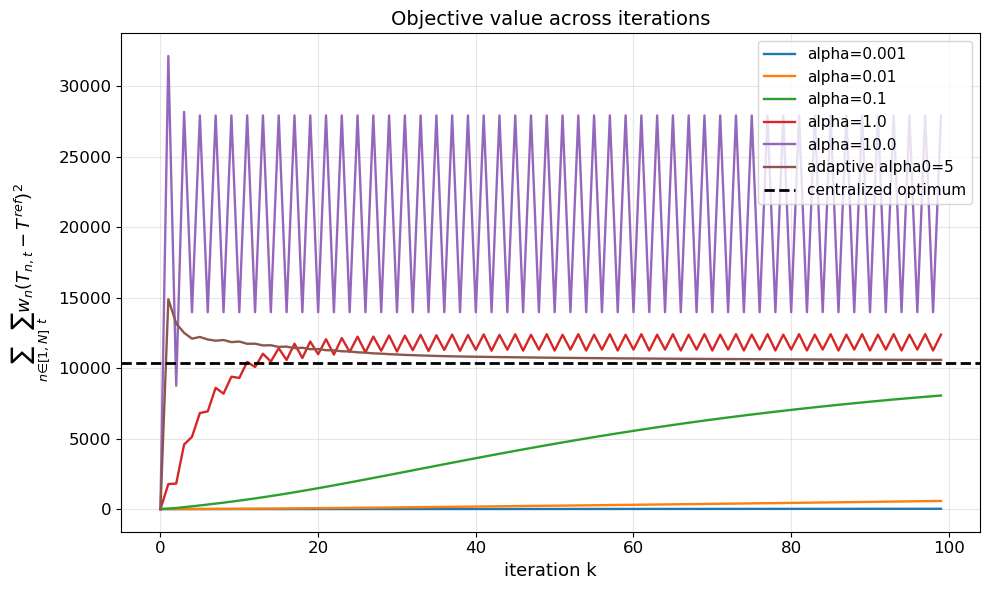

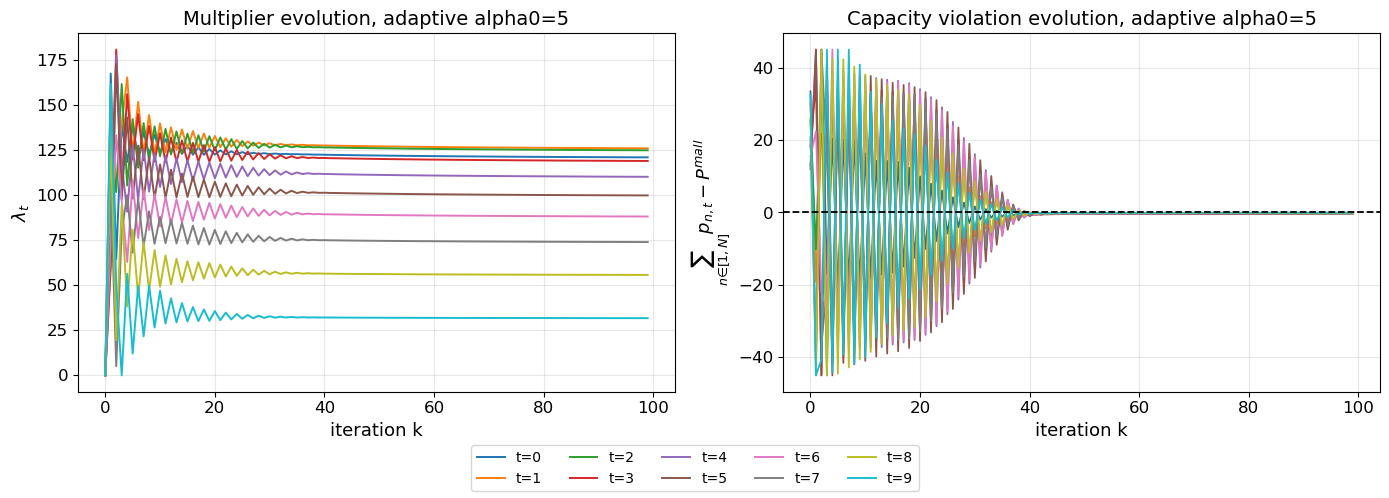

In [11]:
plot_objectives(results, central_obj)

results_best_alpha = {"adaptive alpha0=5": results["adaptive alpha0=5"]}

plot_lambdas_and_violations(results_best_alpha)

## 6. Store Energy Summary

The adaptive alpha version is considered further. Total energy consumption of all stores is compared.

In [12]:
def store_energy_summary(data, p_n_t):
    energy = p_n_t.sum(axis=1)
    return pd.DataFrame({
        "store_n": np.arange(1, data["N"] + 1),
        "w_n": data["w_n"],
        "total_heating_energy": energy,
    })

In [13]:
final_p_n_t = results["adaptive alpha0=5"]["p_n_t"][-1]
summary = store_energy_summary(data, final_p_n_t)
summary

,store_n,w_n,total_heating_energy
0,1,2.0,0.000000
1,2,3.0,12.548681
2,3,4.0,20.698707
3,4,5.0,25.588723
4,5,6.0,28.848733
5,6,7.0,31.177312
6,7,8.0,32.923747
7,8,9.0,34.282084
8,9,10.0,35.368754
9,10,11.0,36.257848
